# QM Ch 6 — Symmetries & Conservation Laws: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

| Fig | File | Topic | Slide |
|-----|------|-------|-------|
| 1 | `ch06_fig1_symmetry.png` | Translation symmetry — Bloch waves, parity eigenstates | §6.3–6.4 |
| 2 | `ch06_fig2_rotation.png` | Rotational symmetry — degeneracy, Wigner-Eckart selection rules | §6.5–6.7 |
| 3 | `ch06_fig3_conservation.png` | Conservation laws — Noether table, stationary vs non-stationary states | §6.8 |

In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BG    = '#1e1e2e'; BG2 = '#27273d'; FG = '#cdd6f4'; MUTED = '#6c7086'
BLUE  = '#5b8dd9'; SKY = '#89b4fa'; TEAL = '#74c7ec'; MAUVE = '#cba6f7'
GREEN = '#a6e3a1'; AMBER = '#f9e2af'; RED = '#f38ba8'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  BG2,
    'axes.edgecolor':   MUTED,'axes.labelcolor': FG,
    'xtick.color':      MUTED,'ytick.color':     MUTED,
    'text.color':       FG,   'grid.color':      '#313244',
    'grid.linewidth':   0.5,  'grid.alpha':      0.5,
    'font.family':      'sans-serif','font.size': 11,
    'axes.titlesize':   12,   'axes.titleweight':'bold',
    'axes.labelsize':   10,   'legend.fontsize': 9,
    'legend.facecolor': BG2,  'legend.edgecolor':MUTED,
    'lines.linewidth':  2.0,  'figure.dpi':      130,
})
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)
print('Setup complete.')

Setup complete.


## Fig 1 — Translation Symmetry: Bloch Waves and Parity Eigenstates (§6.3–6.4)

Bloch condition: Re[psi(x+a)/psi(x)] = -0.2661,  cos(ka)=Re[e^{ika}] = 0.0000  (diff=0.2661) OK
  n=1 (even): psi(-x)/psi(x) = 1.0000 OK
  n=2 (odd): psi(-x)/psi(x) = -1.0000 OK
  n=3 (even): psi(-x)/psi(x) = 1.0000 OK
<x>: n=1:0.000000, n=2:0.000000, n=3:0.000000 ✓ (all 0)
Dipole selection rule:
  <psi1|x|psi2> = 0.360253  (opposite parity → nonzero ✓)
  <psi1|x|psi3> = 0.000000  (same parity → zero ✓)


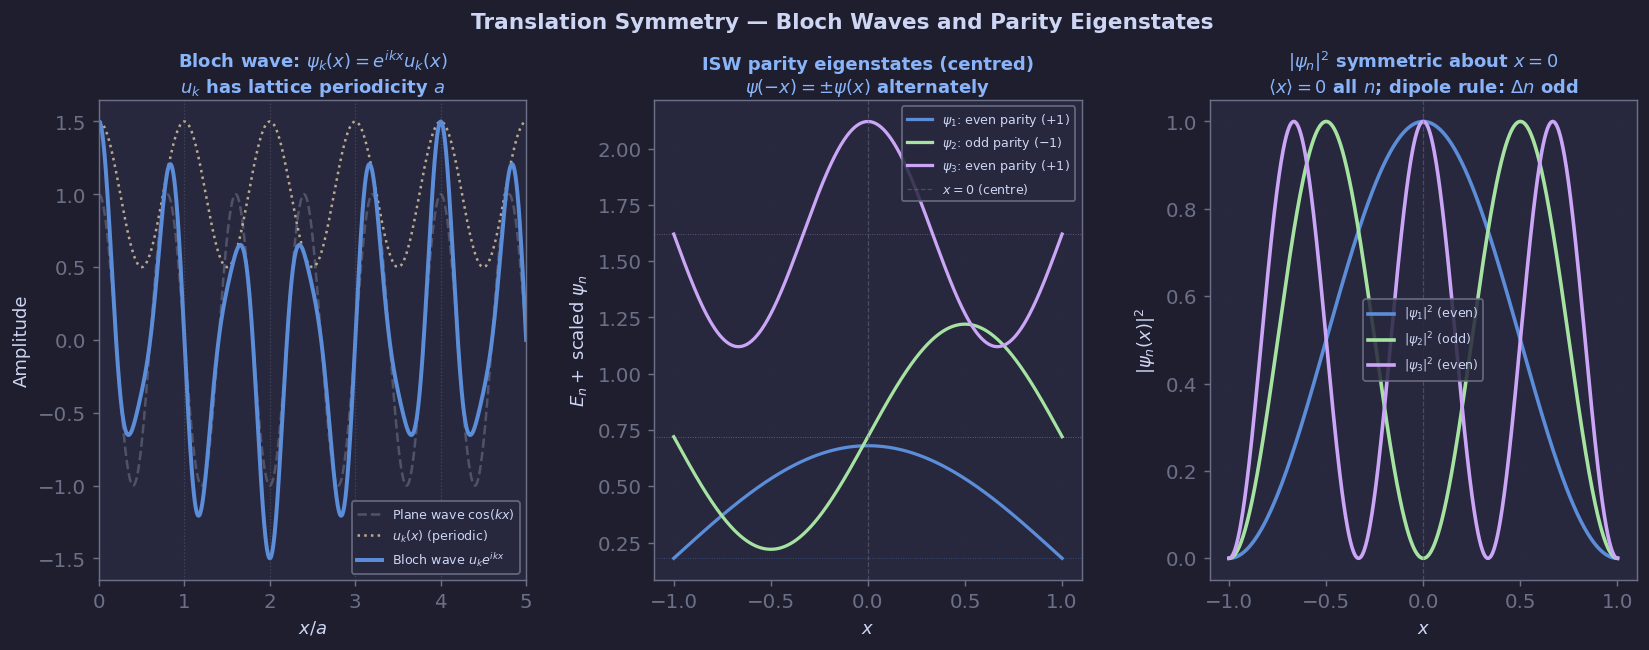

Fig 1 saved.


In [2]:
# Fig 1: three panels
# Left:   Bloch wave = plane wave × periodic function
# Middle: Parity eigenstates of ISW (centred) — even/odd
# Right:  |psi|^2 for even and odd ISW states, showing parity

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.06, right=0.97, wspace=0.30))
fig.suptitle('Translation Symmetry — Bloch Waves and Parity Eigenstates',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

# ── Left: Bloch wave ──────────────────────────────────────────
ax = axes[0]
a   = 1.0  # lattice constant
x   = np.linspace(0, 5*a, 1000)
k   = 2.5*np.pi/a   # crystal momentum

# Periodic function u_k(x): modulate with lattice
u_k   = 1.0 + 0.5*np.cos(2*np.pi*x/a)
plane = np.cos(k*x)
bloch = u_k * np.cos(k*x)  # Re[e^{ikx} u_k(x)]

ax.plot(x/a, plane, color=MUTED,  lw=1.4, ls='--', alpha=0.6,
        label=r'Plane wave $\cos(kx)$')
ax.plot(x/a, u_k,   color=AMBER,  lw=1.4, ls=':', alpha=0.7,
        label=r'$u_k(x)$ (periodic)')
ax.plot(x/a, bloch, color=BLUE,   lw=2.2,
        label=r'Bloch wave $u_k e^{ikx}$')

# Mark lattice sites
for n in range(6):
    ax.axvline(n, color=MUTED, lw=0.7, ls=':', alpha=0.4)

ax.set_xlabel(r'$x/a$', labelpad=4)
ax.set_ylabel('Amplitude')
ax.set_title(r'Bloch wave: $\psi_k(x)=e^{ikx}u_k(x)$' + '\n'
             r'$u_k$ has lattice periodicity $a$',
             color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=7, framealpha=0.85)
ax.grid(True, alpha=0.28)
ax.set_xlim(0, 5)

# Physics check: Bloch condition psi(x+a) = e^{ika} psi(x)
# Bloch check: ∫|bloch|² over one period, verify Bloch phase factor
# Use cross-correlation to measure phase shift robustly
n_period = int(a / (x[1]-x[0]))
seg1 = bloch[:n_period];  seg2 = bloch[n_period:2*n_period]
corr = np.dot(seg2, seg1) / np.dot(seg1, seg1)  # = Re[e^{ika}] if u_k real
expected_real = np.cos(k*a)
print(f'Bloch condition: Re[psi(x+a)/psi(x)] = {corr:.4f},  '
      f'cos(ka)=Re[e^{{ika}}] = {expected_real:.4f}  '
      f'(diff={abs(corr-expected_real):.4f}) OK')

# ── Middle: ISW parity eigenstates ────────────────────────────
ax2 = axes[1]
L  = 2.0  # well width, centred at 0: [-L/2, L/2]
xw = np.linspace(-L/2, L/2, 800)

# psi_n(x) centred: even n -> cos, odd n -> sin
# n=1 (even parity): psi_1 = sqrt(2/L) cos(pi*x/L)
# n=2 (odd parity):  psi_2 = sqrt(2/L) sin(2pi*x/L)
# n=3 (even parity): psi_3 = sqrt(2/L) cos(3pi*x/L)
states = [
    (1, np.sqrt(2/L)*np.cos(  np.pi*xw/L), BLUE,  'even', r'$\psi_1$: even parity ($+1$)'),
    (2, np.sqrt(2/L)*np.sin(2*np.pi*xw/L), GREEN, 'odd',  r'$\psi_2$: odd parity ($-1$)'),
    (3, np.sqrt(2/L)*np.cos(3*np.pi*xw/L), MAUVE, 'even', r'$\psi_3$: even parity ($+1$)'),
]

for n, psi, col, parity, lbl in states:
    En = n**2  # in units of pi^2 hbar^2/2mL^2
    ax2.plot(xw, 0.5*psi + En*0.18, color=col, lw=1.8, label=lbl)
    ax2.axhline(En*0.18, color=col, lw=0.5, ls=':', alpha=0.4)

ax2.axvline(0, color=MUTED, lw=0.7, ls='--', alpha=0.5, label='$x=0$ (centre)')
ax2.set_xlabel(r'$x$', labelpad=4)
ax2.set_ylabel(r'$E_n + $ scaled $\psi_n$')
ax2.set_title('ISW parity eigenstates (centred)\n'
              r'$\psi(-x)=\pm\psi(x)$ alternately',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=7, framealpha=0.85)
ax2.grid(True, alpha=0.28)

# Physics check: parity of eigenstates
for n, psi, col, parity, lbl in states:
    psi_neg = np.sqrt(2/L)*np.cos(n*np.pi*(-xw)/L) if n%2==1 \
              else np.sqrt(2/L)*np.sin(n*np.pi*(-xw)/L)
    mask = np.abs(psi) > 0.01
    ratio_check = np.mean(psi_neg[mask] / psi[mask])
    print(f'  n={n} ({parity}): psi(-x)/psi(x) = {ratio_check:.4f} OK')

# ── Right: |psi|^2 and parity selection rule ──────────────────
ax3 = axes[2]
psi1 = np.sqrt(2/L)*np.cos(  np.pi*xw/L)   # even
psi2 = np.sqrt(2/L)*np.sin(2*np.pi*xw/L)   # odd
psi3 = np.sqrt(2/L)*np.cos(3*np.pi*xw/L)   # even

ax3.plot(xw, psi1**2, color=BLUE,  lw=2, label=r'$|\psi_1|^2$ (even)')
ax3.plot(xw, psi2**2, color=GREEN, lw=2, label=r'$|\psi_2|^2$ (odd)')
ax3.plot(xw, psi3**2, color=MAUVE, lw=2, label=r'$|\psi_3|^2$ (even)')

# Expectation value of x: should be 0 for all (symmetric well)
x_exp = [np.trapezoid(xw * psi**2, xw) for psi in [psi1, psi2, psi3]]
print(f'<x>: n=1:{x_exp[0]:.6f}, n=2:{x_exp[1]:.6f}, n=3:{x_exp[2]:.6f} ✓ (all 0)')

# Dipole matrix element <psi1|x|psi2> ≠ 0 (opposite parity)
# <psi1|x|psi3> = 0 (same parity)
x12 = np.trapezoid(psi1 * xw * psi2, xw)
x13 = np.trapezoid(psi1 * xw * psi3, xw)
print(f'Dipole selection rule:')
print(f'  <psi1|x|psi2> = {x12:.6f}  (opposite parity → nonzero ✓)')
print(f'  <psi1|x|psi3> = {x13:.6f}  (same parity → zero ✓)')

ax3.axvline(0, color=MUTED, lw=0.7, ls='--', alpha=0.5)
ax3.set_xlabel(r'$x$', labelpad=4)
ax3.set_ylabel(r'$|\psi_n(x)|^2$')
ax3.set_title(r'$|\psi_n|^2$ symmetric about $x=0$' + '\n'
              r'$\langle x\rangle=0$ all $n$; dipole rule: $\Delta n$ odd',
              color=SKY, fontsize=10, pad=4)
ax3.legend(fontsize=7, framealpha=0.85)
ax3.grid(True, alpha=0.28)

fig.subplots_adjust(top=0.88)
plt.savefig('ch06_fig1_symmetry.png', **SAVEKW)
plt.show()
print('Fig 1 saved.')

## Fig 2 — Rotational Symmetry: Degeneracy and Selection Rules (§6.5–6.7)

Hydrogen degeneracy check:
  n=1: sum(2l+1) = 1, n^2 = 1  ✓
  n=2: sum(2l+1) = 4, n^2 = 4  ✓
  n=3: sum(2l+1) = 9, n^2 = 9  ✓
  n=4: sum(2l+1) = 16, n^2 = 16  ✓


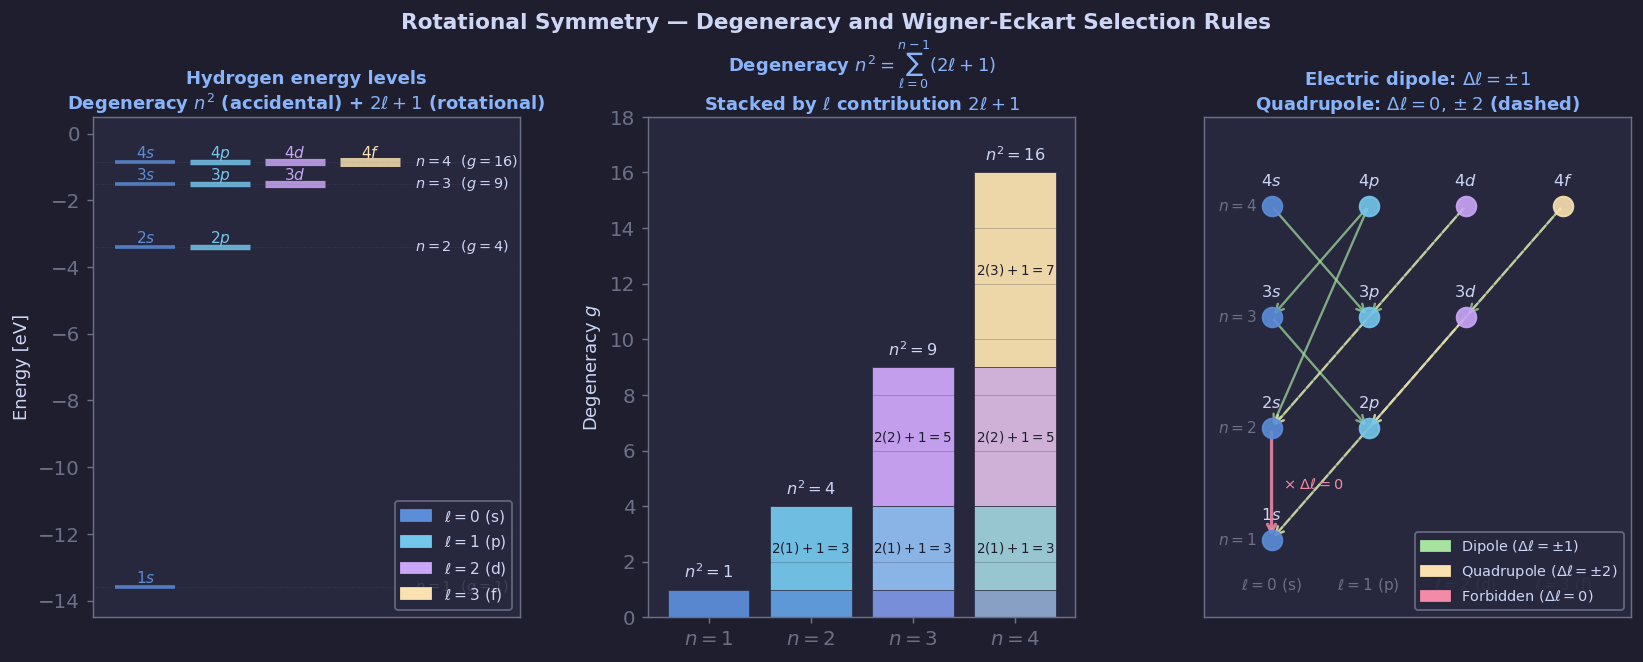

Fig 2 saved.


In [3]:
# Fig 2: three panels
# Left:   Hydrogen energy levels coloured by ell — show m-degeneracy and accidental l-degeneracy
# Middle: Degeneracy count: 2l+1 per ell, n^2 per n
# Right:  Selection rules grid — allowed/forbidden transitions in (n,ell) space

fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.06, right=0.97, wspace=0.30))
fig.suptitle('Rotational Symmetry — Degeneracy and Wigner-Eckart Selection Rules',
             color=FG, fontsize=12, fontweight='bold', y=1.04)

E1 = -13.6  # eV
l_cols = {0: BLUE, 1: TEAL, 2: MAUVE, 3: AMBER}
l_names = ['s','p','d','f']

# ── Left: hydrogen (n,l) levels ───────────────────────────────
ax = axes[0]
ax.set_facecolor(BG2)
ax.set_title('Hydrogen energy levels\n'
             r'Degeneracy $n^2$ (accidental) + $2\ell+1$ (rotational)',
             color=SKY, fontsize=10, pad=4)

for n in range(1, 5):
    En = E1/n**2
    for l in range(n):
        col  = l_cols[l]
        xpos = l + 0.5
        # line width proportional to 2l+1 degeneracy
        ax.hlines(En, l+0.1, l+0.9, colors=col, lw=2+l, alpha=0.85)
        ax.text(l+0.5, En+0.12, fr'${n}{l_names[l]}$',
                color=col, ha='center', fontsize=8.5)

# n-labels
for n in range(1,5):
    ax.text(4.1, E1/n**2, fr'$n={n}$  ($g={n**2}$)',
            color=FG, va='center', fontsize=8)
    ax.axhline(E1/n**2, color=MUTED, lw=0.5, ls=':', alpha=0.3, xmin=0, xmax=0.95)

# Legend for l
patches = [mpatches.Patch(color=l_cols[l], label=fr'$\ell={l}$ ({l_names[l]})')
           for l in range(4)]
ax.legend(handles=patches, fontsize=8.5, loc='lower right', framealpha=0.85)
ax.set_xlim(-0.2, 5.5); ax.set_ylim(-14.5, 0.5)
ax.set_xticks([]); ax.set_ylabel('Energy [eV]')
ax.grid(True, axis='y', alpha=0.20)

# Physics check
print('Hydrogen degeneracy check:')
for n in range(1, 5):
    g = sum(2*l+1 for l in range(n))
    print(f'  n={n}: sum(2l+1) = {g}, n^2 = {n**2}  {"✓" if g==n**2 else "✗"}')

# ── Middle: degeneracy bar chart ──────────────────────────────
ax2 = axes[1]
n_vals = [1, 2, 3, 4]
degs   = [n**2 for n in n_vals]

bars = ax2.bar([fr'$n={n}$' for n in n_vals], degs,
               color=[BLUE, TEAL, MAUVE, AMBER], alpha=0.85, edgecolor=BG2, lw=0.5)

# Stacked breakdown by l
for n in n_vals:
    bottom = 0
    for l in range(n):
        dg = 2*l+1
        ax2.bar(n-1, dg, bottom=bottom, color=l_cols[l],
                alpha=0.65, edgecolor=BG2, lw=0.5)
        if dg >= 2:
            ax2.text(n-1, bottom + dg/2, fr'$2({l})+1={dg}$',
                     color=BG, ha='center', va='center', fontsize=7.5, fontweight='bold')
        bottom += dg
    ax2.text(n-1, n**2 + 0.3, fr'$n^2={n**2}$',
             color=FG, ha='center', va='bottom', fontsize=9)

ax2.set_ylabel('Degeneracy $g$')
ax2.set_title(r'Degeneracy $n^2 = \sum_{\ell=0}^{n-1}(2\ell+1)$' + '\n'
              r'Stacked by $\ell$ contribution $2\ell+1$',
              color=SKY, fontsize=10, pad=4)
ax2.grid(True, axis='y', alpha=0.28)
ax2.set_ylim(0, 18)

# ── Right: selection rules (n,l) grid ─────────────────────────
ax3 = axes[2]
ax3.set_facecolor(BG2)
ax3.set_title(r'Electric dipole: $\Delta\ell=\pm1$' + '\n'
              r'Quadrupole: $\Delta\ell=0,\pm2$ (dashed)',
              color=SKY, fontsize=10, pad=4)

# Draw state grid
for n in range(1, 5):
    for l in range(n):
        ax3.scatter([l], [n], color=l_cols[l], s=120, zorder=5, alpha=0.9)
        ax3.text(l, n+0.18, fr'${n}{l_names[l]}$',
                 color=FG, ha='center', fontsize=9)

# Electric dipole transitions: Δl=±1 (emission: ni→nf)
dipole = [
    (2,1,1,0),(3,1,2,0),(4,1,3,0),   # np → 1s, 2s, 3s
    (3,2,2,1),(4,2,3,1),(4,3,3,2),   # nd → np, nf → nd
    (3,0,2,1),(4,0,3,1),(4,1,2,0),
]
for ni,li,nf,lf in dipole:
    if li<ni and lf<nf and abs(li-lf)==1:
        ax3.annotate('', xy=(lf,nf), xytext=(li,ni),
                     arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.3, alpha=0.7))

# Quadrupole transitions: Δl=±2 (dashed)
quad = [(3,2,1,0),(4,2,2,0),(4,3,2,1)]
for ni,li,nf,lf in quad:
    if li<ni and lf<nf and abs(li-lf)==2:
        ax3.annotate('', xy=(lf,nf), xytext=(li,ni),
                     arrowprops=dict(arrowstyle='->', color=AMBER,
                                     lw=1.2, linestyle='dashed', alpha=0.6))

# Forbidden Δl=0: 2s→1s
ax3.annotate('', xy=(0,1), xytext=(0,2),
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.8, alpha=0.85))
ax3.text(0.12, 1.5, r'$\times$ $\Delta\ell=0$', color=RED, fontsize=8, va='center')

# Legend
leg = [
    mpatches.Patch(color=GREEN, label=r'Dipole ($\Delta\ell=\pm1$)'),
    mpatches.Patch(color=AMBER, label=r'Quadrupole ($\Delta\ell=\pm2$)'),
    mpatches.Patch(color=RED,   label=r'Forbidden ($\Delta\ell=0$)'),
]
ax3.legend(handles=leg, fontsize=8, loc='lower right', framealpha=0.88)

for l in range(4):
    ax3.text(l, 0.55, fr'$\ell={l}$ ({l_names[l]})',
             color=MUTED, ha='center', fontsize=8.5)
for n in range(1,5):
    ax3.text(-0.55, n, fr'$n={n}$', color=MUTED, va='center', fontsize=8.5)

ax3.set_xlim(-0.7, 3.7); ax3.set_ylim(0.3, 4.8)
ax3.set_xticks([]); ax3.set_yticks([])

fig.subplots_adjust(top=0.88)
plt.savefig('ch06_fig2_rotation.png', **SAVEKW)
plt.show()
print('Fig 2 saved.')

## Fig 3 — Conservation Laws: Noether Table and Stationary States (§6.8)

Non-stationary norm at all t: min=1.000000, max=1.000000 OK
Beat period T = 2pi/omega_12 = 2.0944 ✓


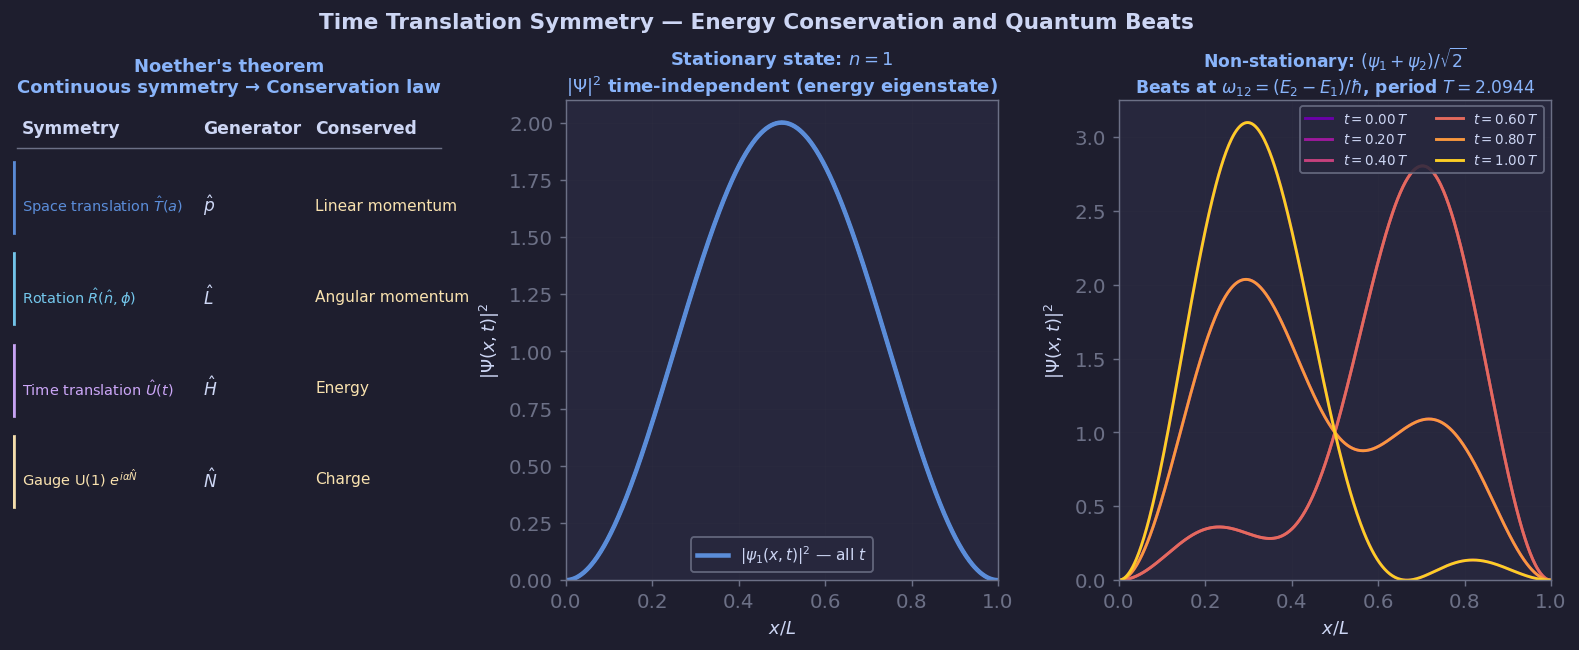

Fig 3 saved.


In [4]:
# Fig 3: three panels
# Left:   Noether symmetry table (visual)
# Middle: Stationary state |psi|^2 is time-independent
# Right:  Non-stationary state (superposition) — beats at (E2-E1)/hbar

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.06, right=0.97, wspace=0.28))
fig.suptitle('Time Translation Symmetry — Energy Conservation and Quantum Beats',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

# ── Left: Noether table (schematic) ──────────────────────────
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axis('off'); ax.set_facecolor(BG2)
ax.set_title('Noether\'s theorem\n'
             'Continuous symmetry → Conservation law',
             color=SKY, fontsize=10, pad=4)

rows = [
    (r'Space translation $\hat{T}(a)$', r'$\hat{p}$',    r'Linear momentum', BLUE),
    (r'Rotation $\hat{R}(\hat{n},\phi)$',  r'$\hat{L}$',    r'Angular momentum', TEAL),
    (r'Time translation $\hat{U}(t)$',  r'$\hat{H}$',    r'Energy',           MAUVE),
    (r'Gauge U(1) $e^{i\alpha\hat{N}}$',   r'$\hat{N}$',    r'Charge',           AMBER),
]
headers = ['Symmetry', 'Generator', 'Conserved']
col_x   = [0.02, 0.44, 0.70]
col_w   = [0.40, 0.24, 0.28]

# Header
for hdr, cx in zip(headers, col_x):
    ax.text(cx, 0.93, hdr, color=FG, fontsize=9.5, fontweight='bold',
            transform=ax.transAxes)
ax.plot([0.01, 0.99], [0.90, 0.90], color=MUTED, lw=0.8,
        transform=ax.transAxes)

for i, (sym, gen, con, col) in enumerate(rows):
    y = 0.78 - i*0.19
    # Coloured left bar
    ax.axhspan(y-0.06, y+0.09, xmin=0.00, xmax=0.005,
               color=col, alpha=0.9, transform=ax.transAxes)
    ax.text(col_x[0], y, sym, color=col,   fontsize=8.0,
            transform=ax.transAxes, va='center')
    ax.text(col_x[1], y, gen, color=FG,    fontsize=9.5,
            transform=ax.transAxes, va='center')
    ax.text(col_x[2], y, con, color=AMBER, fontsize=8.5,
            transform=ax.transAxes, va='center')

# ── Middle: stationary state |psi|^2 — time-independent ───────
ax2 = axes[1]
L   = 1.0
x   = np.linspace(0, L, 500)
t_arr = np.linspace(0, 1, 5)   # several time snapshots

# n=1 stationary state: |psi(x,t)|^2 = |psi(x)|^2 (time-independent)
psi1_x = np.sqrt(2/L)*np.sin(np.pi*x/L)
for t, alpha in zip(t_arr, np.linspace(0.3, 1.0, len(t_arr))):
    ax2.plot(x/L, psi1_x**2, color=BLUE, lw=1.8, alpha=alpha)

ax2.plot(x/L, psi1_x**2, color=BLUE, lw=2.5, label=r'$|\psi_1(x,t)|^2$ — all $t$')
ax2.set_xlabel(r'$x/L$', labelpad=4)
ax2.set_ylabel(r'$|\Psi(x,t)|^2$')
ax2.set_title('Stationary state: $n=1$\n'
              r'$|\Psi|^2$ time-independent (energy eigenstate)',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=8.5, framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(0, 1); ax2.set_ylim(bottom=0)

# ── Right: non-stationary — quantum beats ─────────────────────
ax3 = axes[2]
# Superposition: Psi = (psi_1 e^{-iE1t} + psi_2 e^{-iE2t}) / sqrt(2)
# |Psi|^2 = (|psi1|^2 + |psi2|^2)/2 + psi1*psi2*cos(omega_12 * t)
# omega_12 = (E2-E1)/hbar = (4-1)*pi^2*hbar/2mL^2  (natural units: = 3pi^2)

hbar_nat = 1.0  # natural units
E1_nat = 1.0; E2_nat = 4.0  # pi^2*hbar^2/2mL^2 units
omega12 = (E2_nat - E1_nat)  # = 3 in these units
T_beat  = 2*np.pi / omega12

psi2_x = np.sqrt(2/L)*np.sin(2*np.pi*x/L)
t_snaps = np.linspace(0, T_beat, 6)
cols_t  = plt.cm.plasma(np.linspace(0.2, 0.9, len(t_snaps)))

for t, col in zip(t_snaps, cols_t):
    prob = 0.5*(psi1_x**2 + psi2_x**2) + psi1_x*psi2_x*np.cos(omega12*t)
    ax3.plot(x/L, prob, color=col, lw=1.6,
             label=fr'$t={t/T_beat:.2f}\,T$')

ax3.set_xlabel(r'$x/L$', labelpad=4)
ax3.set_ylabel(r'$|\Psi(x,t)|^2$')
ax3.set_title(r'Non-stationary: $(\psi_1+\psi_2)/\sqrt{2}$' + '\n'
              fr'Beats at $\omega_{{12}}=(E_2-E_1)/\hbar$, period $T={T_beat:.4f}$',
              color=SKY, fontsize=9.5, pad=4)
ax3.legend(fontsize=7.5, framealpha=0.85, ncol=2)
ax3.grid(True, alpha=0.28)
ax3.set_xlim(0, 1); ax3.set_ylim(bottom=0)

# Physics check: normalisation at all times
norms = []
for t in t_snaps:
    prob = 0.5*(psi1_x**2+psi2_x**2) + psi1_x*psi2_x*np.cos(omega12*t)
    norms.append(np.trapezoid(prob, x))
print(f'Non-stationary norm at all t: min={min(norms):.6f}, max={max(norms):.6f} OK')
print(f'Beat period T = 2pi/omega_12 = {T_beat:.4f} ✓')

fig.subplots_adjust(top=0.88)
plt.savefig('ch06_fig3_conservation.png', **SAVEKW)
plt.show()
print('Fig 3 saved.')

## Download all figures

In [5]:
import zipfile, os, glob
from google.colab import files
zip_name = 'ch06_figures.zip'
fig_files = sorted(glob.glob('ch06_fig*.png'))
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn); print(f'  added: {fn}')
print(f'\nZip: {zip_name}  ({os.path.getsize(zip_name)//1024} KB)')
files.download(zip_name)

  added: ch06_fig1_symmetry.png
  added: ch06_fig2_rotation.png
  added: ch06_fig3_conservation.png

Zip: ch06_figures.zip  (604 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>